# 04 - Market Basket Analysis

Runs the Apriori algorithm (via `mlxtend`) on the itemized orders in `order_history_clean.csv` to find food items that are frequently ordered together, per the README's Market Basket Analysis component - support, confidence, and lift for each rule.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

PROCESSED = Path("../Data/processed")

# Dataviz palette (validated: see project's dataviz skill / references/palette.md)
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
SEQ_SINGLE = "#2a78d6"
SEQ_BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
seq_cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE_RAMP)

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "axes.grid": True,
        "grid.color": GRIDLINE,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "figure.dpi": 110,
    }
)

order_history = pd.read_csv(PROCESSED / "order_history_clean.csv")
print(order_history.shape)
order_history[["order_id", "items_in_order", "item_count"]].head()

(21321, 29)


,order_id,items_in_order,item_count
0,6168884918,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",2
1,6170707559,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",3
2,6169375019,1 x Bone in Peri Peri Grilled Chicken,1
3,6151677434,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",2
4,6167540897,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",2


## 1. Build the Transaction Basket

`items_in_order` is a free-text string like `"1 x Grilled Chicken Jamaican Tender, 1 x Grilled Chicken Peri Peri Tangdi"`. Re-parse it into a plain list of item names per order (dropping quantity - Apriori only cares whether an item was in the basket), then one-hot encode with `TransactionEncoder` into the item x order matrix Apriori expects.

In [2]:
def extract_items(text):
    return [
        m.group(1).strip()
        for part in str(text).split(",")
        if (m := re.match(r"\s*\d+\s*x\s*(.+)", part.strip()))
    ]


baskets = order_history["items_in_order"].apply(extract_items).tolist()

te = TransactionEncoder()
onehot = pd.DataFrame(te.fit(baskets).transform(baskets), columns=te.columns_)

basket_sizes = pd.Series([len(b) for b in baskets])
print(f"{onehot.shape[0]:,} orders, {onehot.shape[1]} distinct items")
print(f"{(basket_sizes >= 2).sum():,} orders ({(basket_sizes >= 2).mean():.0%}) have 2+ items - only these can form a rule")

21,321 orders, 244 distinct items
11,694 orders (55%) have 2+ items - only these can form a rule


## 2. Frequent Itemsets

`min_support=0.003` (an item combination appearing in at least ~64 of the 21,321 orders) was chosen by checking the support/itemset-count trade-off directly: 0.005 leaves only 18 multi-item itemsets (too sparse to find real patterns), while 0.002 nearly doubles the single-item noise without adding meaningful multi-item combinations. 0.003 is the point where itemsets of size 2+ are still plentiful without letting through one-off coincidences.

In [3]:
MIN_SUPPORT = 0.003

frequent_itemsets = apriori(onehot, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print(f"{len(frequent_itemsets)} frequent itemsets ({(frequent_itemsets['length'] > 1).sum()} with 2+ items)")
frequent_itemsets.sort_values("support", ascending=False).head(10)

119 frequent itemsets (41 with 2+ items)


,support,itemsets,length
8,0.146147,(Bageecha Pizza),1
18,0.082032,(Chilli Cheese Garlic Bread),1
3,0.076497,(All About Chicken Pizza),1
11,0.076497,(Bone in Jamaican Grilled Chicken),1
49,0.068055,(Makhani Paneer Pizza),1
51,0.062849,(Margherita Pizza),1
16,0.054172,(Cheesy Garlic Bread),1
46,0.053844,(Jamaican Chicken Melt),1
77,0.042681,(Tripple Cheese Pizza),1
42,0.041274,(Herbed Potato),1


## 3. Association Rules

Generate rules from the frequent itemsets, filtered to `lift > 1` (the pair co-occurs more than chance would predict - `lift <= 1` means the items are independent or negatively associated, which isn't a cross-sell opportunity).

In [4]:
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=1.0, num_itemsets=len(frequent_itemsets)
)
rules["antecedents_str"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequents_str"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"{len(rules)} rules")
rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(15)

62 rules


,antecedents_str,consequents_str,support,confidence,lift
0,Murgh Amritsari Seekh Pide,Mutton Seekh Pide,0.003283,0.119658,9.177089
1,Mutton Seekh Pide,Murgh Amritsari Seekh Pide,0.003283,0.251799,9.177089
2,Grilled Chicken Smoky BBQ Tender,Grilled Chicken Jamaican Tender,0.003002,0.165375,6.089730
3,Grilled Chicken Jamaican Tender,Grilled Chicken Smoky BBQ Tender,0.003002,0.110535,6.089730
4,Murgh Amritsari Seekh Melt,Jamaican Chicken Melt,0.007364,0.307241,5.706166
5,Jamaican Chicken Melt,Murgh Amritsari Seekh Melt,0.007364,0.136760,5.706166
6,Angara Paneer Melt,Mushroom Mozzarella Melt,0.003893,0.124625,4.985219
7,Mushroom Mozzarella Melt,Angara Paneer Melt,0.003893,0.155722,4.985219
8,Fried Chicken Peri Peri Tender,Animal Fries,0.003377,0.129264,3.739533
9,Animal Fries,Fried Chicken Peri Peri Tender,0.003377,0.097693,3.739533


## 4. Visualize the Rules

Left: every rule plotted by support vs. confidence, colored by lift on the sequential blue ramp (lift is a magnitude here, not a category, so one hue is the right encoding - a colorbar replaces a legend). Right: the top 15 rules ranked by lift, as a single-hue bar chart consistent with every other ranking chart in this project.

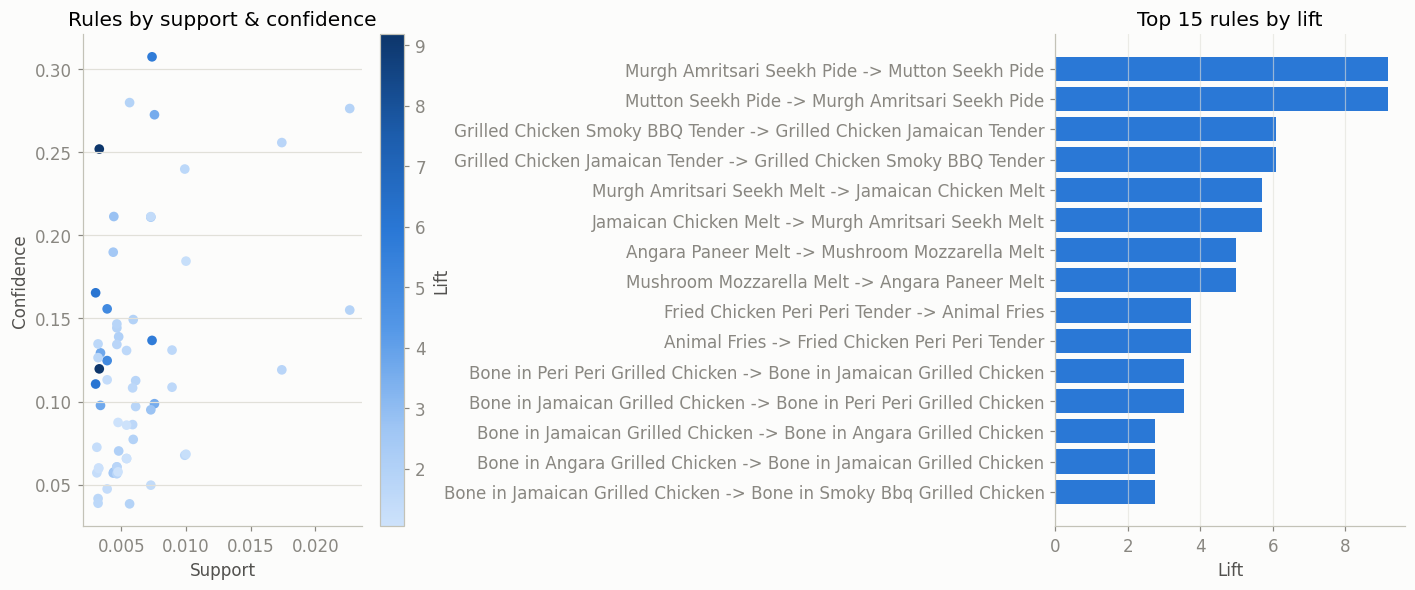

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sc = axes[0].scatter(
    rules["support"], rules["confidence"], c=rules["lift"], cmap=seq_cmap, s=40, edgecolor="none"
)
axes[0].set_xlabel("Support")
axes[0].set_ylabel("Confidence")
axes[0].set_title("Rules by support & confidence")
axes[0].grid(axis="x", visible=False)
fig.colorbar(sc, ax=axes[0], label="Lift")

top_rules = rules.head(15).iloc[::-1]
labels = top_rules["antecedents_str"] + " -> " + top_rules["consequents_str"]
axes[1].barh(labels, top_rules["lift"], color=SEQ_SINGLE)
axes[1].set_xlabel("Lift")
axes[1].set_title("Top 15 rules by lift")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", alpha=0.6)

fig.tight_layout()
plt.show()

## 5. Business Reading

The README's illustrative combos (Pizza -> Coke, Burger -> Fries) are generic - this restaurant's actual top rules are almost entirely **flavor-variant pairs of the same dish** (e.g. `Murgh Amritsari Seekh Pide -> Mutton Seekh Pide`, `Bone in Peri Peri Grilled Chicken -> Bone in Jamaican Grilled Chicken`), which reads as group orders where different diners pick different flavors of the same item. That's a different but equally actionable cross-sell signal: a "mixed flavor combo" bundle for these pairs is a more natural product than a generic add-on offer.

## 6. Save Rules

In [6]:
output_cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]
output_path = PROCESSED / "association_rules.csv"
rules[output_cols].rename(columns={"antecedents_str": "antecedents", "consequents_str": "consequents"}).to_csv(
    output_path, index=False
)
print(f"Saved {len(rules)} rules to {output_path}")

Saved 62 rules to ..\Data\processed\association_rules.csv


## Summary

`Data/processed/association_rules.csv` holds every rule (antecedent, consequent, support, confidence, lift) for the Power BI dashboard's Market Basket Analysis section and for direct product-recommendation/combo-offer use.

Next: `customer_prediction.ipynb` (retention/repeat-order prediction, using `customer_segments.csv` as a feature source).